# xFormers memo
### マスクの種類

In [1]:
import torch
from xformers.ops import fmha
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def visualize_tiles(matrix):
    plt.figure(figsize=(4, 4))
    sns.heatmap(matrix, cmap="gray", cbar=False, linewidths=0.5, linecolor='gray', square=True)
    plt.xticks([])
    plt.yticks([])
    plt.show()

#### LocalAttentionFromBottomRightMask

In [3]:
bias = fmha.attn_bias.LocalAttentionFromBottomRightMask(window_left=2, window_right=2)
matrix = bias.materialize(shape=(16, 16)).exp()
# print(bias.materialize(shape=(16, 16)).exp())

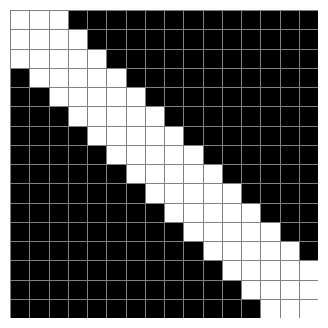

In [4]:
visualize_tiles(matrix)

#### LowerTriangularMask
下三角形（因果関係）マスク

In [95]:
bias = fmha.attn_bias.LowerTriangularMask()
matrix = bias.materialize(shape=(16, 16)).exp()
# print(bias.materialize(shape=(16, 16)).exp())

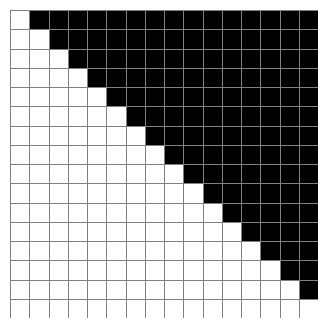

In [96]:
visualize_tiles(matrix)

#### LowerTriangularFromBottomRightMask
下三角形（因果関係）マスク

In [97]:
bias = fmha.attn_bias.LowerTriangularFromBottomRightMask()
matrix = bias.materialize(shape=(16, 16)).exp()
# print(bias.materialize(shape=(16, 16)).exp())

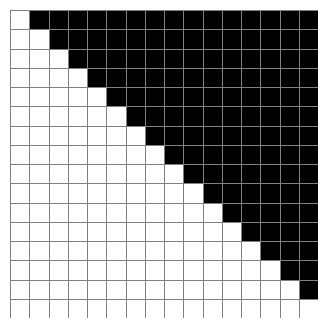

In [98]:
visualize_tiles(matrix)

#### LowerTriangularFromBottomRightLocalAttentionMask
下三角形（因果関係）ローカルマスク

In [99]:
bias = fmha.attn_bias.LowerTriangularFromBottomRightLocalAttentionMask(_window_size=5)
matrix = bias.materialize(shape=(16, 16)).exp()

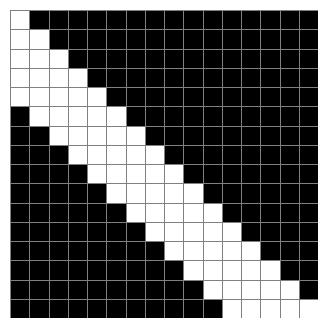

In [100]:
visualize_tiles(matrix)

#### BlockDiagonalMask

In [126]:
# 各ブロックのシーケンス長
block_sizes = [5, 6, 5]

# BlockDiagonalMask を作成
base_mask = fmha.attn_bias.BlockDiagonalMask.from_seqlens(block_sizes)
matrix = base_mask.materialize(shape=(16, 16)).exp()

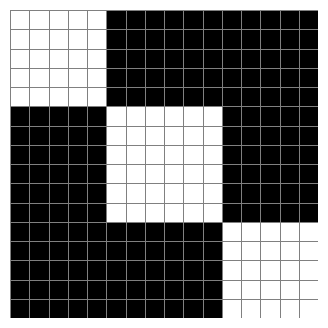

In [127]:
visualize_tiles(matrix)

#### BlockDiagonalCausalMask
`BlockDiagonalMask`の派生クラス。定義の仕方は以下の二つあるが、二つ目が公式。

In [128]:
# 各ブロックのシーケンス長
block_sizes = [5, 6, 5]

# BlockDiagonalCausalMask を作成
causal_mask = fmha.attn_bias.BlockDiagonalCausalMask.from_seqlens(block_sizes)
matrix = causal_mask.materialize(shape=(16, 16)).exp()

In [130]:
causal_mask = fmha.attn_bias.BlockDiagonalMask.make_causal(base_mask)
matrix = causal_mask.materialize(shape=(16, 16)).exp()

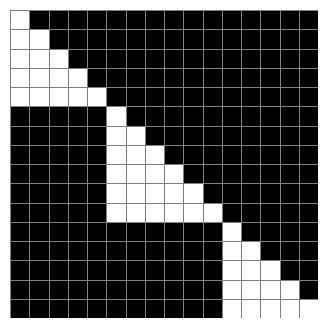

In [131]:
visualize_tiles(matrix)

#### BlockDiagonalCausalFromBottomRightMask
`BlockDiagonalCausalMask`との違いは調査中だが、メモリ消費が少し改善される？

In [116]:
# 各ブロックのシーケンス長
block_sizes = [5, 6, 5]

# BlockDiagonalCausalFromBottomRightMask を作成
causal_mask = fmha.attn_bias.BlockDiagonalCausalFromBottomRightMask.from_seqlens(block_sizes)
matrix = causal_mask.materialize(shape=(16, 16)).exp()

In [132]:
causal_mask = fmha.attn_bias.BlockDiagonalMask.make_causal_from_bottomright(base_mask)
matrix = causal_mask.materialize(shape=(16, 16)).exp()

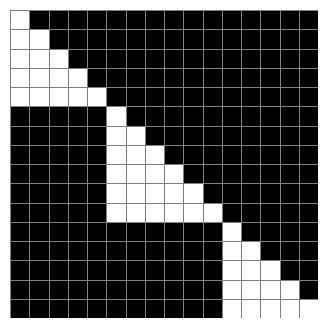

In [133]:
visualize_tiles(matrix)

#### BlockDiagonalCausalLocalAttentionMask

In [147]:
causal_mask = fmha.attn_bias.BlockDiagonalMask.make_local_attention(base_mask, window_size=3)
matrix = causal_mask.materialize(shape=(16, 16)).exp()

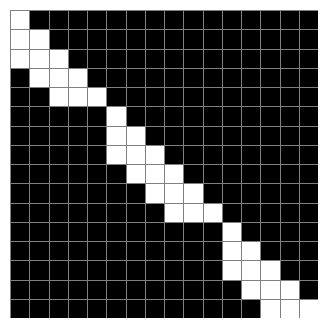

In [148]:
visualize_tiles(matrix)

#### BlockDiagonalCausalLocalAttentionFromBottomRightMask

In [150]:
causal_mask = fmha.attn_bias.BlockDiagonalMask.make_local_attention_from_bottomright(base_mask, window_size=3)
matrix = causal_mask.materialize(shape=(16, 16)).exp()

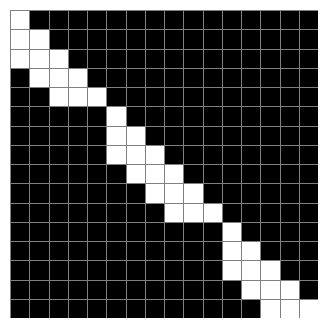

In [151]:
visualize_tiles(matrix)

#### BlockDiagonalPaddedKeysMask

In [180]:
q_seqlen = [5, 6, 5]
kv_seqlen = [5, 6, 5]

# kv_padding は最大の kv_seqlen ではなく、適切なパディング値にする
kv_padding = max(kv_seqlen)  # もしくは 8 など適切な値

base_mask = fmha.attn_bias.BlockDiagonalPaddedKeysMask.from_seqlens(
    q_seqlen=q_seqlen, kv_padding=kv_padding, kv_seqlen=kv_seqlen
)

# shape を修正
matrix = base_mask.materialize(shape=(sum(q_seqlen), kv_padding * len(kv_seqlen))).exp()

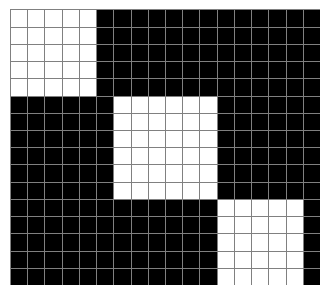

In [181]:
visualize_tiles(matrix)

#### BlockDiagonalCausalWithOffsetPaddedKeysMask

In [178]:
q_seqlen = [5, 6, 5]
kv_seqlen = [5, 6, 5]

# kv_padding は最大の kv_seqlen ではなく、適切なパディング値にする
kv_padding = max(kv_seqlen)  # もしくは 8 など適切な値

base_mask = fmha.attn_bias.BlockDiagonalCausalWithOffsetPaddedKeysMask.from_seqlens(
    q_seqlen=q_seqlen, kv_padding=kv_padding, kv_seqlen=kv_seqlen
)

# shape を修正
matrix = base_mask.materialize(shape=(sum(q_seqlen), kv_padding * len(kv_seqlen))).exp()

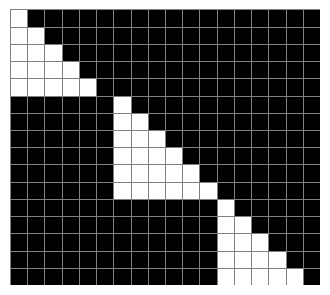

In [179]:
visualize_tiles(matrix)

In [ ]:
base_mask = fmha.attn_bias.BlockDiagonalGappyKeysMask.from_seqlens()